<a href="https://colab.research.google.com/github/SampMark/Deep-Learning/blob/main/Autoencoder_Model_using_Keras_and_MNIST_dataset_consolidated.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Implatanção de um modelo de Autoencoder usando Keras e o dataset MNIST**

Este notebook oferece uma exploração didática e abrangente de implantação dos autoencoders para aprendizado não supervisionado, usando o Keras e o dataset MNIST. Exploraremos do básico até variações mais aplicáveis, permitindo um ótimo entendimento prático e teórico.

Como sabemos, o aprendizado não supervisionado tem por objetivo encontrar uma "estrutura intrínseca", isto é, padrões ou representações em dados **não rotulados** ($X = \{x^{(1)}, x^{(2)}, ..., x^{(m)}\}$). Suas aplicações incluem redução de dimensionalidade, _clustering_, detecção de anomalias e aprendizado de _features_. Vale salientar que o conceito de autoencoders foi explorado desde os anos 1980, com trabalhos influentes como os de Hinton e Rumelhart _et al._, (1986). Uma referência recente e abrangente é o Capítulo 14 do livro **Deep Learning** de Goodfellow et al. (2016).

## **Definição**

Autoencoders são um tipo de rede neural para aprendizado não supervisionado usada para aprender representações (codificações) eficientes de dados, aprendendo a reconstruir sua própria entrada. Tipicamente são utilizadsas para redução de dimensionalidade ou aprendizado de características. O autoencoder tenta aprender uma função identidade: $$h_{W,b}(x) \approx x$$

Possuem as seguintes componentes principais:
* **Codificador (Encoder)**: responsável por comprimir a entrada numa representação de espaço latente.
  * $f_\theta(x)$: mapeia a entrada $x \in \mathbb{R}^D$ para uma representação latente (oculta) $z \in \mathbb{R}^d$, onde $d < D$ (para autoencoders subcompletos/undercomplete).

  $$z = f_\theta(x) = \sigma(W_1 x + b_1)$$

* **Gargalo (Bottleneck)**: é uma representação comprimida que contém as características mais importantes, é a camada $z$ com a menor dimensionalidade.

* **Decodificador (Decoder)**: tem o papel de reconstruir a entrada a partir da representação do espaço latente.
  * $g_\phi(z)$: mapeia a representação latente $z$ de volta para o espaço de entrada, produzindo a reconstrução $\hat{x} \in \mathbb{R}^D$. $\hat{x} = g_\phi(z) = \sigma'(W_2 z + b_2)$.

O objetivo do treinamento é minimizar a diferença (erro de reconstrução) entre os dados de entrada e os dados reconstruídos pelo decoder, ou seja, visa minimizar a diferença entre a entrada e a saída reconstruída, forçando a rede a aprender representações significativas.

Entre as aplicações principais dos Autoencoders estão a redução de dimensionalidade, remoção de ruído (_data denoising_) e aprendizado de características (_feature learning_).

## **Tipos de Autoencoders**

* **Básico**: possui estrutura simples, geralmente com uma camada oculta no encoder e uma no decoder.
* **Variacional (VAEs)**: introduzem elementos probabilísticos e são usados para gerar novas amostras de dados.
* **Convolucional**: utilizam camadas convolucionais, sendo muito eficazes para dados de imagem.

## **Exploração de Variações**

Neste notebook avançaremos para tópicos importantes como:
* Ajuste Fino (Fine-tuning)
* **Denoising Autoencoder**: aplicação prática e importante dos autoencoders.
* Impacto do tamanho do Bottleneck: demonstrando-se experimentalmente como a capacidade do gargalo afeta a reconstrução.
* Regularização L2: introdução da técnica para combater o overfitting.
* Visualização do espaço latente: Tenta visualizar as características codificadas, o que é um passo importante na compreensão do que o encoder aprendeu.

In [1]:
# Alocação de uma GPU
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

Thu May  8 23:15:30 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   47C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!pip install tensorflow

### **Modelo de Autoencoders com Keras e MNIST**

Este notebook abrange:
1. Autoencoder Básico para Reconstrução.
2. Treinamento de Denoising Autoencoder.
3. Experimento com diferentes tamanhos de Bottleneck.
4. Uso de Regularização L2.
5. Visualização do Espaço Latente.


In [3]:
# --- 1. Importações e Configurações Iniciais ---
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2
from sklearn.manifold import TSNE # Para visualização do espaço latente

print(f"TensorFlow Versão: {tf.__version__}")

TensorFlow Versão: 2.18.0


In [4]:
# @title --- 2. Constantes e Hiperparâmetros ---
IMG_ROWS, IMG_COLS = 28, 28
INPUT_DIM = IMG_ROWS * IMG_COLS  # 784, dimensão da entrada achatada

# Hiperparâmetros de Treinamento
EPOCHS_INITIAL = 25       # Épocas para o treinamento inicial do autoencoder
EPOCHS_DENOISING = 20     # Épocas para o Denoising Autoencoder
EPOCHS_BOTTLENECK = 20    # Épocas para o teste de bottlenecks
EPOCHS_REGULARIZED = 50   # Épocas para o autoencoder regularizado
BATCH_SIZE = 256
PATIENCE_EARLY_STOP = 5   # Paciência para o EarlyStopping

# Dimensões da arquitetura do autoencoder base
ENCODING_DIM_1 = 64
BOTTLENECK_DIM_DEFAULT = 32

# Parâmetros do Denoising Autoencoder
NOISE_FACTOR = 0.5

In [5]:
# @title --- 3. Carregamento e Pré-processamento do Dataset MNIST ---
print("\n--- Carregando e Pré-processando o Dataset MNIST ---")
# Carrega os dados de treino e teste. Rótulos (y_train, y_test) são carregados para visualização do espaço latente.
(x_train_raw, y_train_raw), (x_test_raw, y_test_raw) = mnist.load_data()

# Normalização dos pixels para o intervalo [0.0, 1.0]
x_train_norm = x_train_raw.astype('float32') / 255.
x_test_norm = x_test_raw.astype('float32') / 255.

# Achatamento (Flattening) das imagens
# Transforma as imagens 2D (28x28) em vetores 1D (784)
x_train_flat = x_train_norm.reshape((len(x_train_norm), INPUT_DIM))
x_test_flat = x_test_norm.reshape((len(x_test_norm), INPUT_DIM))

print(f"Forma dos dados de treino originais (raw): {x_train_raw.shape}")
print(f"Forma dos dados de teste originais (raw): {x_test_raw.shape}")
print(f"Forma dos dados de treino achatados e normalizados: {x_train_flat.shape}")
print(f"Forma dos dados de teste achatados e normalizados: {x_test_flat.shape}")
print(f"Valores mínimos e máximos (treino normalizado): {np.min(x_train_flat)}, {np.max(x_train_flat)}")


--- Carregando e Pré-processando o Dataset MNIST ---
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Forma dos dados de treino originais (raw): (60000, 28, 28)
Forma dos dados de teste originais (raw): (10000, 28, 28)
Forma dos dados de treino achatados e normalizados: (60000, 784)
Forma dos dados de teste achatados e normalizados: (10000, 784)
Valores mínimos e máximos (treino normalizado): 0.0, 1.0



Exibindo amostras das imagens de teste originais (raw)...


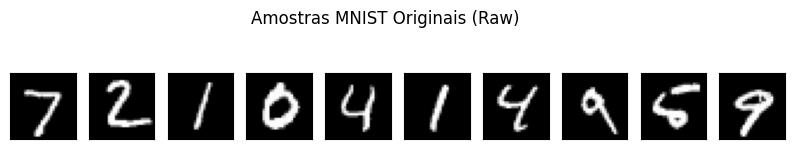

In [6]:
# Visualizar algumas imagens originais (pré-normalização) para referência
print("\nExibindo amostras das imagens de teste originais (raw)...")
plt.figure(figsize=(10, 2))
for i in range(10):
    ax = plt.subplot(1, 10, i + 1)
    plt.imshow(x_test_raw[i], cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.suptitle("Amostras MNIST Originais (Raw)")
plt.show()

## **Arquitetura do Modelo Autoencoder** (`build_autoencoder_model`)
Esta função modulariza a criação do autoencoder, o que torna o código mais limpo e reutilizável nos diferentes experimentos que se seguem.
### **Argumentos**
Recebe as dimensões da entrada, da primeira camada de codificação, do _bottleneck_ e, opcionalmente, um regularizador de kernel.

### **Arquitetura:**
1. **Entrada** (`Input`), define a camada de entrada que espera vetores com `input_dim` características.
2. **Codificador** (Encoder): mapeia a entrada $x \in \mathbb{R}^{\text{input\_dim}}$ para uma representação latente $z \in \mathbb{R}^{\text{bottleneck\_dim}}$.

  Consiste em duas camadas `Dense`:

  $$x \rightarrow \mathbb{R}^{\text{encoding\_dim\_1}} \rightarrow \mathbb{R}^{\text{bottleneck\_dim}}$$

  Usa ativação `relu` ($f(a) = \max(0, a)$) nas camadas ocultas, que ajuda a mitigar o problema do desaparecimento do gradiente e introduz não-linearidade.

3. **Decodificador** (Decoder): mapeia a representação latente $z$ de volta para o espaço de entrada, produzindo a reconstrução $\hat{x} \in \mathbb{R}^{\text{input\_dim}}$.

  Espelha a arquitetura do encoder:

  $$z \rightarrow \mathbb{R}^{\text{encoding\_dim\_1}} \rightarrow \mathbb{R}^{\text{input\_dim}}$$

Também usa `relu` nas camadas ocultas.

4. A camada de **saída** usa ativação `sigmoid` ($\sigma(a) = 1 / (1 + e^{-a})$), que gera valores entre 0 e 1, compatíveis com os dados de entrada normalizados.

5. **Regularizador de Kernel**(`kernel_regularizer`): Permite adicionar regularização L1 ou L2 aos pesos (kernels) das camadas densas para combater o overfitting, se desejado.
6. **Compilação:**
  * `optimizer='adam'`: otimizador Adam, eficiente e adaptativo.
  * `loss='binary_crossentropy'`: função de perda adequada para reconstrução de imagens normalizadas para \[0,1] com saída sigmoide. A qual mede a "distância" entre a distribuição de Bernoulli de cada pixel reconstruído e o pixel original. Para um pixel $y$ (original) e $\hat{y}$ (reconstruído), a perda é $-[y \log(\hat{y}) + (1-y) \log(1-\hat{y})]$. A média é calculada sobre todos os pixels e amostras.

In [7]:
# @title --- 4. Função para Construir o Modelo Autoencoder ---
def build_autoencoder_model(input_dim, encoding_dim_1, bottleneck_dim, kernel_reg=None):
    """
    Constrói e compila um modelo autoencoder denso.

    Args:
        input_dim (int): Dimensão da camada de entrada (e saída).
        encoding_dim_1 (int): Número de neurônios na primeira camada do encoder (e última do decoder).
        bottleneck_dim (int): Número de neurônios na camada de gargalo (bottleneck).
        kernel_reg (tf.keras.regularizers.Regularizer, optional): Regularizador a ser aplicado
                                                                  aos kernels das camadas densas.
                                                                  Default None.

    Returns:
        tensorflow.keras.models.Model: O modelo Keras autoencoder compilado.
    """
    # Camada de Entrada
    input_layer = Input(shape=(input_dim,), name='Entrada_Achatada')

    # Encoder
    encoded_l1 = Dense(encoding_dim_1, activation='relu', kernel_regularizer=kernel_reg, name='Encoder_L1')(input_layer)
    bottleneck_l = Dense(bottleneck_dim, activation='relu', kernel_regularizer=kernel_reg, name=f'Bottleneck_{bottleneck_dim}')(encoded_l1)

    # Decoder
    decoded_l1 = Dense(encoding_dim_1, activation='relu', kernel_regularizer=kernel_reg, name='Decoder_L1')(bottleneck_l)
    output_layer = Dense(input_dim, activation='sigmoid', kernel_regularizer=kernel_reg, name='Saida_Reconstruida')(decoded_l1)

    # Modelo Autoencoder
    autoencoder = Model(inputs=input_layer, outputs=output_layer, name=f'Autoencoder_BN{bottleneck_dim}')

    # Compilação
    autoencoder.compile(optimizer='adam', loss='binary_crossentropy') # Removida métrica 'accuracy'

    return autoencoder

## **Funções utilitárias para Plotagem**

* `plot_training_history`: plota as curvas de perda de treinamento e validação ao longo das épocas. Essencial para monitorar a convergência e detectar _overfitting_.

* `visualize_reconstructions`: exibe uma grade comparando imagens originais com suas versões reconstruídas pelo autoencoder, permitindo uma avaliação qualitativa.

In [8]:
# @title --- 5. Função para Plotar Histórico de Treinamento ---
def plot_training_history(history, title_suffix=""):
    """Plota a perda de treinamento e validação."""
    plt.figure(figsize=(10, 5))
    plt.plot(history.history['loss'], label='Perda de Treinamento')
    plt.plot(history.history['val_loss'], label='Perda de Validação')
    plt.title(f'Histórico de Perda {title_suffix}')
    plt.ylabel('Perda (Binary Crossentropy)')
    plt.xlabel('Época')
    plt.legend(loc='upper right')
    plt.grid(True)
    plt.show()

In [9]:
# @title --- 6. Função para Visualizar Reconstruções ---
def visualize_reconstructions(original_data, reconstructed_data, num_images=10, title_prefix=""):
    """Exibe imagens originais lado a lado com suas reconstruções."""
    plt.figure(figsize=(20, 4))
    for i in range(num_images):
        # Imagem Original
        ax = plt.subplot(2, num_images, i + 1)
        plt.imshow(original_data[i].reshape(IMG_ROWS, IMG_COLS), cmap='gray')
        plt.title("Original")
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

        # Imagem Reconstruída
        ax = plt.subplot(2, num_images, i + 1 + num_images)
        plt.imshow(reconstructed_data[i].reshape(IMG_ROWS, IMG_COLS), cmap='gray')
        plt.title("Reconstruída")
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)
    plt.suptitle(f"{title_prefix}Imagens Originais vs. Reconstruídas", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

### **Experimento 1: Autoencoder Básico**
* **Construção:** um autoencoder é criado usando a função `build_autoencoder_model` com as dimensões padrão (bottleneck de 32).
* **Early Stopping:** um _callback_ `EarlyStopping` é definido para monitorar a `val_loss`, será interrompido o treinamento se a perda na validação não melhorar por `PATIENCE_EARLY_STOP` épocas consecutivas e restaurará os melhores pesos encontrados. Isso ajuda a evitar o _overfitting_ e a economizar tempo de treinamento.
* **Treinamento:** o modelo é treinado usando `x_train_flat` tanto como entrada (`X`) quanto como alvo (`y`), pois o objetivo é reconstruir a própria entrada. `shuffle=True` embaralha os dados de treino a cada época.
* **Avaliação:** a perda no conjunto de teste é calculada e impressa.
* **Visualização:** as reconstruções são exibidas. Espera-se que as imagens reconstruídas se pareçam com as originais, embora possam estar um pouco borradas, especialmente com um _bottleneck_ restritivo.

In [10]:
# @title --- EXPERIMENTO 1: AUTOENCODER BÁSICO ---
print("\n--- EXPERIMENTO 1: Autoencoder Básico ---")
autoencoder_base = build_autoencoder_model(INPUT_DIM, ENCODING_DIM_1, BOTTLENECK_DIM_DEFAULT)
print("Resumo do Autoencoder Básico:")
autoencoder_base.summary()

# Callback de Early Stopping
early_stopping_cb = EarlyStopping(monitor='val_loss', patience=PATIENCE_EARLY_STOP, restore_best_weights=True, verbose=1)

print("\nTreinando Autoencoder Básico...")
history_base = autoencoder_base.fit(
    x_train_flat, x_train_flat,
    epochs=EPOCHS_INITIAL,
    batch_size=BATCH_SIZE,
    shuffle=True,
    validation_data=(x_test_flat, x_test_flat),
    callbacks=[early_stopping_cb],
    verbose=1
)


--- EXPERIMENTO 1: Autoencoder Básico ---
Resumo do Autoencoder Básico:


Model: "Autoencoder_BN32"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ Entrada_Achatada (InputLayer)        │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Encoder_L1 (Dense)                   │ (None, 64)                  │          50,240 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Bottleneck_32 (Dense)                │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Decoder_L1 (Dense)                   │ (None, 64)                  │           2,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Saida_Reconstruida (Dense)           │ (None, 784)                 │          50,960 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 105,392 (411.69 KB)

 Trainable params: 105,392 (411.69 KB)

 Non-trainable params: 0 (0.00 B)


Treinando Autoencoder Básico...
Epoch 1/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.3687 - val_loss: 0.1780
Epoch 2/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1710 - val_loss: 0.1427
Epoch 3/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1383 - val_loss: 0.1245
Epoch 4/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1239 - val_loss: 0.1172
Epoch 5/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1173 - val_loss: 0.1129
Epoch 6/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1138 - val_loss: 0.1098
Epoch 7/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1107 - val_loss: 0.1078
Epoch 8/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1079 - val_loss: 0.1040
Epoch 9/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.1050 - val_loss: 0.1017
Epoch 10/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1029 - val_loss: 0.1001
Epoch 11/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1014 - val_loss: 0.0990
Epoch 12/25
235/23

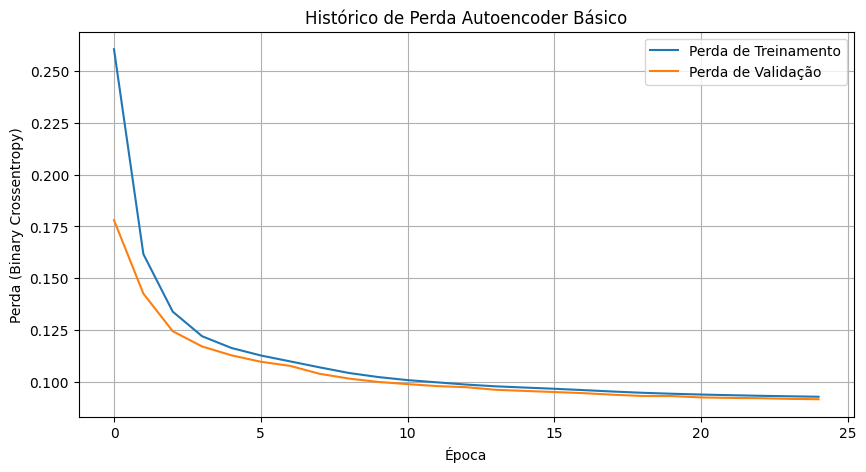


Avaliando Autoencoder Básico no conjunto de teste...
Perda no Teste (Autoencoder Básico): 0.091763


In [11]:
# Visualizar o histórico de treinamento

plot_training_history(history_base, "Autoencoder Básico")

print("\nAvaliando Autoencoder Básico no conjunto de teste...")
loss_base = autoencoder_base.evaluate(x_test_flat, x_test_flat, verbose=0)
print(f"Perda no Teste (Autoencoder Básico): {loss_base:.6f}")


Visualizando reconstruções do Autoencoder Básico...
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


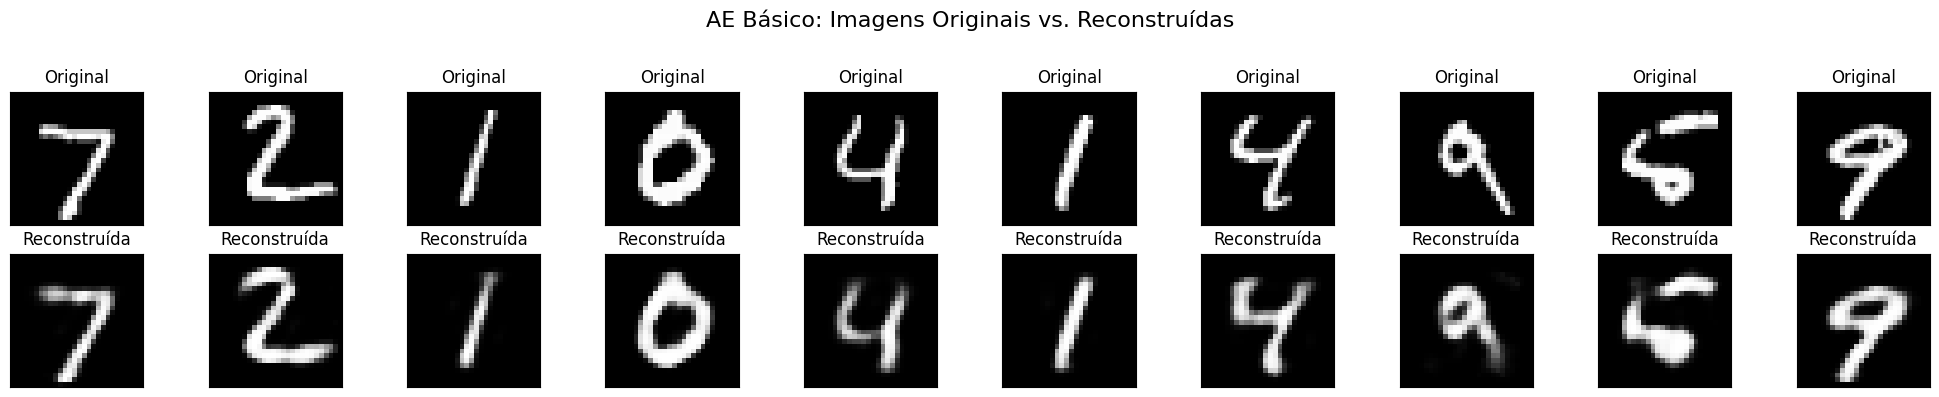

In [12]:
# Visualizar reconstruções do Autoencoder Básico
print("\nVisualizando reconstruções do Autoencoder Básico...")
reconstructed_imgs_base = autoencoder_base.predict(x_test_flat)
visualize_reconstructions(x_test_flat, reconstructed_imgs_base, title_prefix="AE Básico: ")

## **Experimento 2: Denoising Autoencoder (DAE)**
O DAE é treinado para reconstruir uma imagem *limpa* a partir de uma versão *ruidosa* da mesma, forçando o modelo a aprender características mais robustas e a ignorar o ruído. Conforme passos a seguir:
* **Geração de Ruído:** ruído Gaussiano é adicionado aos dados de treino e teste normalizados e achatados (`x_train_flat`, `x_test_flat`). O `NOISE_FACTOR` controla a intensidade do ruído.
* **Clipping:** `np.clip` é usado para garantir que os valores dos pixels ruidosos permaneçam no intervalo válido `[0.0, 1.0]`.
* **Treinamento:** Um novo modelo DAE (com a mesma arquitetura base) é treinado. Crucialmente, a entrada (`X`) é `x_train_noisy_flat` (dados ruidosos) e o alvo (`y`) é `x_train_flat` (dados limpos).
* **Avaliação:** A perda é calculada usando `x_test_noisy_flat` como entrada e `x_test_flat` como alvo.

Ao final são exibidas três imagens: a entrada ruidosa, a saída "denoised" (reconstruída) pelo DAE, e a imagem original limpa para comparação. Com efeito, a saída do DAE é mais limpa que a entrada ruidosa e próxima da original.

In [17]:
# @title --- EXPERIMENTO 2: DENOISING AUTOENCODER ---
print("\n--- EXPERIMENTO 2: Denoising Autoencoder ---")
print(f"Gerando dados ruidosos com noise_factor = {NOISE_FACTOR}...")
noise = NOISE_FACTOR * np.random.normal(loc=0.0, scale=1.0, size=x_train_flat.shape)
x_train_noisy_flat = x_train_flat + noise
noise = NOISE_FACTOR * np.random.normal(loc=0.0, scale=1.0, size=x_test_flat.shape)
x_test_noisy_flat = x_test_flat + noise

# Clipping dos valores para o intervalo [0, 1]
x_train_noisy_flat = np.clip(x_train_noisy_flat, 0., 1.)
x_test_noisy_flat = np.clip(x_test_noisy_flat, 0., 1.)
print("Dados ruidosos gerados.")

# Construir um novo modelo para o Denoising AE ou re-treinar o anterior
# Para este exemplo, vamos construir um novo para clareza e evitar
# sobrescrever o modelo base já treinado.
denoising_autoencoder = build_autoencoder_model(INPUT_DIM, ENCODING_DIM_1, BOTTLENECK_DIM_DEFAULT)
print("Resumo do Denoising Autoencoder:")
denoising_autoencoder.summary()


--- EXPERIMENTO 2: Denoising Autoencoder ---
Gerando dados ruidosos com noise_factor = 0.5...
Dados ruidosos gerados.
Resumo do Denoising Autoencoder:


Model: "Autoencoder_BN32"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Entrada_Achatada (InputLayer)   │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Encoder_L1 (Dense)              │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Bottleneck_32 (Dense)           │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Decoder_L1 (Dense)              │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Saida_Reconstruida (Dense)      │ (None, 784)            │        50,960 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 105,392 (411.69 KB)

 Trainable params: 105,392 (411.69 KB)

 Non-trainable params: 0 (0.00 B)


Treinando Denoising Autoencoder...
Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.3570 - val_loss: 0.2063
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1927 - val_loss: 0.1704
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1686 - val_loss: 0.1609
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1605 - val_loss: 0.1545
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1538 - val_loss: 0.1481
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1480 - val_loss: 0.1440
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1440 - val_loss: 0.1411
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1409 - val_loss: 0.1383
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1391 - val_loss: 0.1368
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1371 - val_loss: 0.1351
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1362 - val_loss: 0.1345
Epoch 12/20
235/

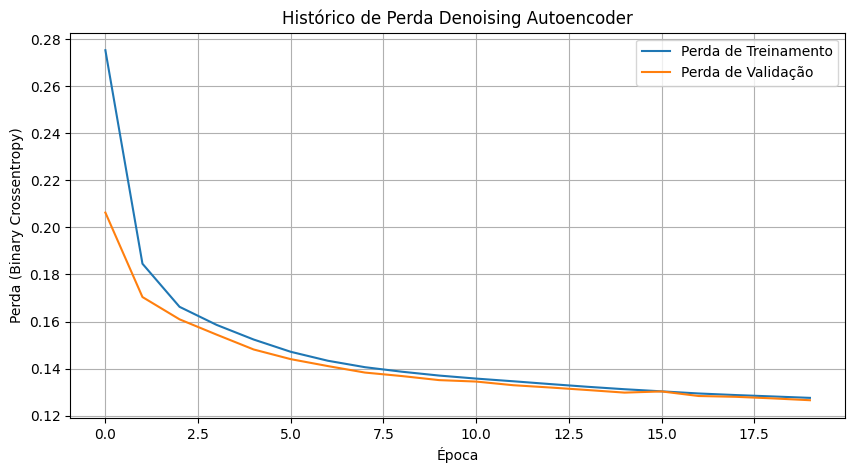


Avaliando Denoising Autoencoder...
Perda no Teste (Denoising Autoencoder): 0.126583


In [18]:
# Treinando Denoising Autoencoder

print("\nTreinando Denoising Autoencoder...")
history_denoising = denoising_autoencoder.fit(
    x_train_noisy_flat, x_train_flat, # Entrada RUIDOSA, Alvo LIMPO
    epochs=EPOCHS_DENOISING,
    batch_size=BATCH_SIZE,
    shuffle=True,
    validation_data=(x_test_noisy_flat, x_test_flat),
    callbacks=[early_stopping_cb],
    verbose=1
)

plot_training_history(history_denoising, "Denoising Autoencoder")

print("\nAvaliando Denoising Autoencoder...")
# Avaliar usando entrada ruidosa e alvo limpo
loss_denoising = denoising_autoencoder.evaluate(x_test_noisy_flat, x_test_flat, verbose=0)
print(f"Perda no Teste (Denoising Autoencoder): {loss_denoising:.6f}")


Visualizando reconstruções do Denoising Autoencoder...
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


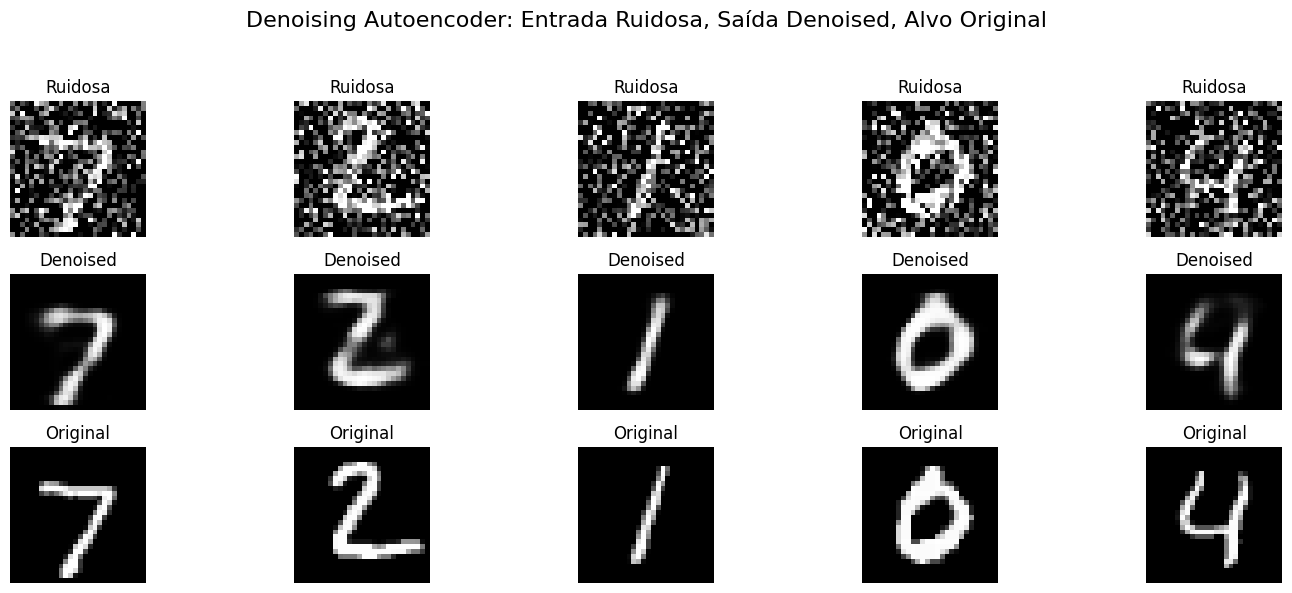

In [19]:
print("\nVisualizando reconstruções do Denoising Autoencoder...")
# Prever a partir de imagens de teste RUIDOSAS
denoised_images = denoising_autoencoder.predict(x_test_noisy_flat)

# Visualizar: Ruidosa (Entrada), Denoised (Saída), Original (Alvo)
num_images_denoising = 5
plt.figure(figsize=(15, 6))
for i in range(num_images_denoising):
    # Imagem Ruidosa
    ax = plt.subplot(3, num_images_denoising, i + 1)
    plt.imshow(x_test_noisy_flat[i].reshape(IMG_ROWS, IMG_COLS), cmap='gray')
    plt.title("Ruidosa")
    ax.axis('off')

    # Imagem Denoised
    ax = plt.subplot(3, num_images_denoising, i + 1 + num_images_denoising)
    plt.imshow(denoised_images[i].reshape(IMG_ROWS, IMG_COLS), cmap='gray')
    plt.title("Denoised")
    ax.axis('off')

    # Imagem Original Limpa
    ax = plt.subplot(3, num_images_denoising, i + 1 + 2 * num_images_denoising)
    plt.imshow(x_test_flat[i].reshape(IMG_ROWS, IMG_COLS), cmap='gray')
    plt.title("Original")
    ax.axis('off')
plt.suptitle("Denoising Autoencoder: Entrada Ruidosa, Saída Denoised, Alvo Original", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## **Experimento 3: Impacto do Tamanho do Bottleneck**
Nesta etapa o oObjetivo será investigar como a capacidade da camada de gargalo (sua dimensionalidade) afeta a qualidade da reconstrução.

#### **Funcionamento**
* **Loop de Treinamento:** vários autoencoders são treinados, cada um com um tamanho de bottleneck diferente (16, 32, 64, 128).
* **Avaliação e Comparação:** a perda de reconstrução no conjunto de teste é calculada e comparada para cada modelo.

#### **Raciocínio Matemático/Teórico**

Um bottleneck menor (e.g., 16) impõe uma compressão maior, forçando o modelo a aprender uma representação $z$ de dimensão muito baixa. Isso pode levar à perda de informação e, consequentemente, a uma maior perda de reconstrução (reconstruções mais pobres).

Já um bottleneck maior (e.g., 128) permite que mais informação passe, geralmente, resultando em menor perda de reconstrução.

No entanto, se o bottleneck for muito grande (próximo da dimensão de entrada), o autoencoder pode simplesmente aprender a função identidade sem extrair características significativas.

Ao final serão plotadas as curvas de perda de validação e os exemplos de reconstruções para diferentes tamanhos de bottleneck para análise visual e quantitativa.

In [20]:
# @title --- EXPERIMENTO 3: IMPACTO DO TAMANHO DO BOTTLENECK ---
print("\n--- EXPERIMENTO 3: Impacto do Tamanho do Bottleneck ---")
bottleneck_sizes_to_test = [16, 32, 64, 128]
trained_bottleneck_models = {}
histories_bottleneck = {}
test_losses_bottleneck = {}

for size in bottleneck_sizes_to_test:
    print(f"\nTreinando Autoencoder com Bottleneck = {size}...")
    model = build_autoencoder_model(INPUT_DIM, ENCODING_DIM_1, size)
    model.summary() # Resumo de cada modelo

    history = model.fit(
        x_train_flat, x_train_flat,
        epochs=EPOCHS_BOTTLENECK,
        batch_size=BATCH_SIZE,
        shuffle=True,
        validation_data=(x_test_flat, x_test_flat),
        callbacks=[early_stopping_cb],
        verbose=0 # Menos verboso para este loop
    )
    trained_bottleneck_models[size] = model
    histories_bottleneck[size] = history.history

    loss = model.evaluate(x_test_flat, x_test_flat, verbose=0)
    test_losses_bottleneck[size] = loss
    print(f"  Bottleneck {size}: Perda no Teste = {loss:.6f}")

print("\nComparação da Perda de Reconstrução (Teste) por Tamanho do Bottleneck:")
for size, loss in test_losses_bottleneck.items():
    print(f"  Bottleneck: {size:3d} -> Perda: {loss:.6f}")


--- EXPERIMENTO 3: Impacto do Tamanho do Bottleneck ---

Treinando Autoencoder com Bottleneck = 16...


Model: "Autoencoder_BN16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Entrada_Achatada (InputLayer)   │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Encoder_L1 (Dense)              │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Bottleneck_16 (Dense)           │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Decoder_L1 (Dense)              │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Saida_Reconstruida (Dense)      │ (None, 784)            │        50,960 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 103,328 (403.62 KB)

 Trainable params: 103,328 (403.62 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Entrada_Achatada (InputLayer)   │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Encoder_L1 (Dense)              │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Bottleneck_128 (Dense)          │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Decoder_L1 (Dense)              │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Saida_Reconstruida (Dense)      │ (None, 784)            │        50,960 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 117,776 (460.06 KB)

 Trainable params: 117,776 (460.06 KB)

 Non-trainable params: 0 (0.00 B)

Restoring model weights from the end of the best epoch: 20.
  Bottleneck 128: Perda no Teste = 0.081620

Comparação da Perda de Reconstrução (Teste) por Tamanho do Bottleneck:
  Bottleneck:  16 -> Perda: 0.113499
  Bottleneck:  32 -> Perda: 0.092660
  Bottleneck:  64 -> Perda: 0.084950
  Bottleneck: 128 -> Perda: 0.081620


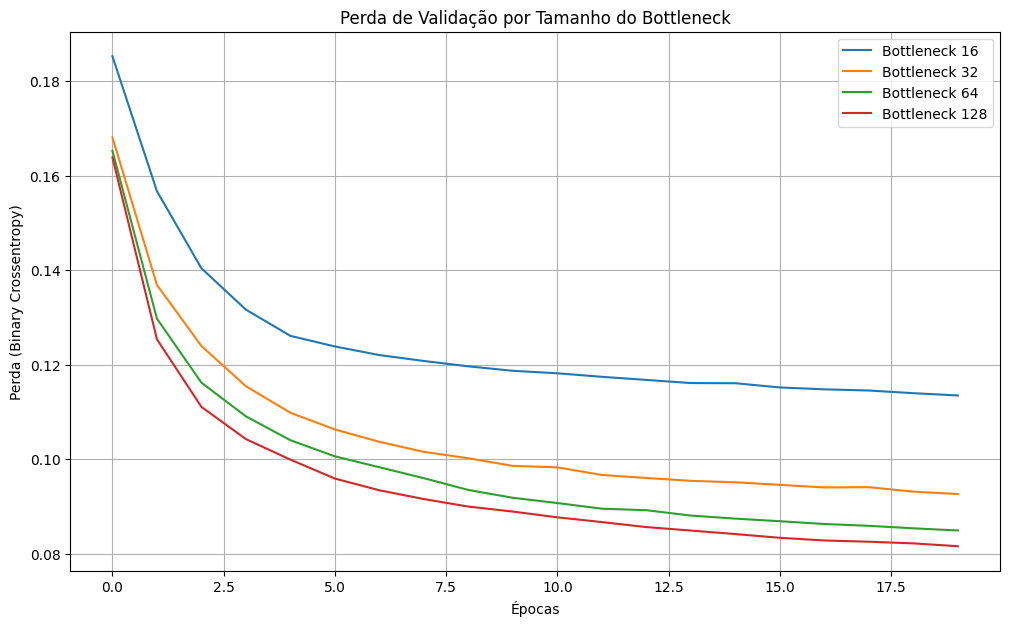

In [21]:
# Visualizar curvas de perda de validação para os diferentes bottlenecks
plt.figure(figsize=(12, 7))
for size in bottleneck_sizes_to_test:
    plt.plot(histories_bottleneck[size]['val_loss'], label=f'Bottleneck {size}')
plt.title('Perda de Validação por Tamanho do Bottleneck')
plt.xlabel('Épocas')
plt.ylabel('Perda (Binary Crossentropy)')
plt.legend()
plt.grid(True)
plt.show()


Visualizando reconstruções para diferentes tamanhos de Bottleneck...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step


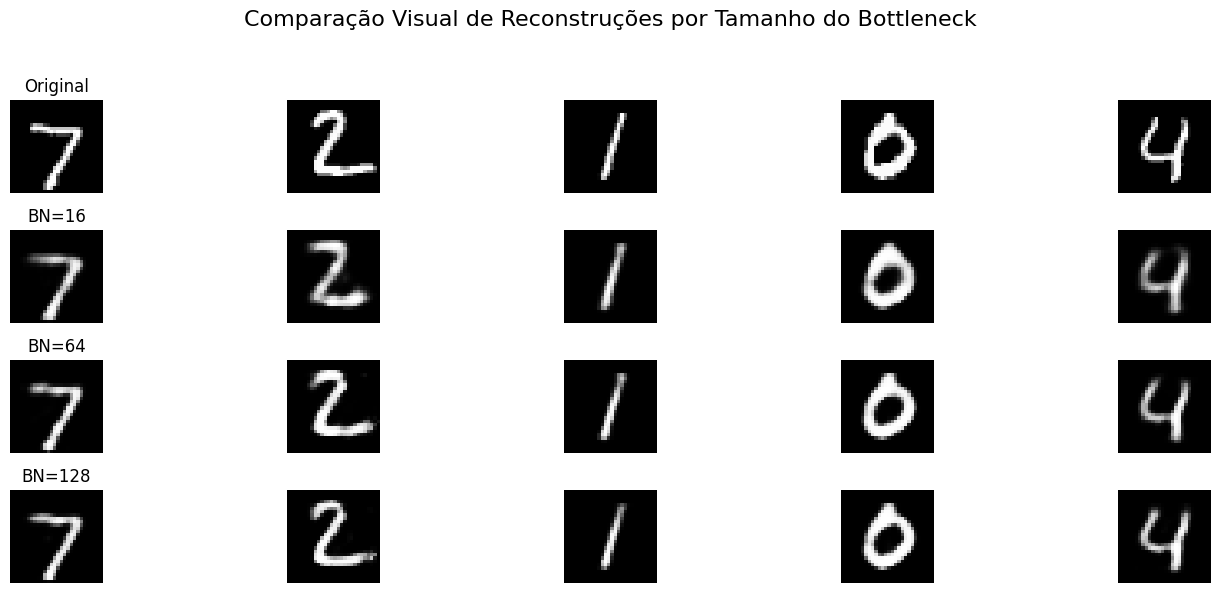

In [22]:
# Visualizar reconstruções para alguns tamanhos de bottleneck
print("\nVisualizando reconstruções para diferentes tamanhos de Bottleneck...")
recons_bn16 = trained_bottleneck_models[16].predict(x_test_flat[:5])
recons_bn64 = trained_bottleneck_models[64].predict(x_test_flat[:5])
if 128 in trained_bottleneck_models:
    recons_bn128 = trained_bottleneck_models[128].predict(x_test_flat[:5])

plt.figure(figsize=(15, 6 if 128 in trained_bottleneck_models else 5))
num_vis_bn = 5
for i in range(num_vis_bn):
    # Original
    ax = plt.subplot(4 if 128 in trained_bottleneck_models else 3, num_vis_bn, i + 1)
    plt.imshow(x_test_flat[i].reshape(IMG_ROWS, IMG_COLS), cmap='gray')
    if i == 0: plt.title("Original")
    ax.axis('off')
    # BN = 16
    ax = plt.subplot(4 if 128 in trained_bottleneck_models else 3, num_vis_bn, i + 1 + num_vis_bn)
    plt.imshow(recons_bn16[i].reshape(IMG_ROWS, IMG_COLS), cmap='gray')
    if i == 0: plt.title("BN=16")
    ax.axis('off')
    # BN = 64
    ax = plt.subplot(4 if 128 in trained_bottleneck_models else 3, num_vis_bn, i + 1 + 2*num_vis_bn)
    plt.imshow(recons_bn64[i].reshape(IMG_ROWS, IMG_COLS), cmap='gray')
    if i == 0: plt.title("BN=64")
    ax.axis('off')
    # BN = 128 (opcional)
    if 128 in trained_bottleneck_models:
        ax = plt.subplot(4, num_vis_bn, i + 1 + 3*num_vis_bn)
        plt.imshow(recons_bn128[i].reshape(IMG_ROWS, IMG_COLS), cmap='gray')
        if i == 0: plt.title("BN=128")
        ax.axis('off')
plt.suptitle("Comparação Visual de Reconstruções por Tamanho do Bottleneck", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## **Experimento 4: Autoencoder com Regularização L2**

A regularização L2 (ou "_weight decay_") é uma técnica para prevenir _overfitting_, adicionando uma penalidade à função de perda proporcional ao quadrado da magnitude dos pesos do modelo.

* **Função de Perda com L2:**

$$L_{total} = L_{reconstrução} + \lambda \sum_{i} w_i^2$$

Onde $w_i$ são os pesos do modelo e $\lambda$ é o fator de regularização.

### **Implementação**

O `kernel_regularizer=l2(REG_FACTOR)` é adicionado a todas as camadas `Dense` ao construir o modelo. O modelo regularizado é treinado e avaliado e a perda reportada incluirá o termo de regularização.
O efeito esperado pode gerar pesos menores e a um modelo que generaliza melhor, especialmente se o modelo base estiver mostrando sinais de _overfitting_, isto é, grande diferença entre perda de treino e validação.

As reconstruções podem parecer um pouco mais "suaves" ou menos propensas a memorizar o ruído dos dados de treino.

In [24]:
# @title --- EXPERIMENTO 4: AUTOENCODER COM REGULARIZAÇÃO L2 ---
print("\n--- EXPERIMENTO 4: Autoencoder com Regularização L2 ---")
REG_FACTOR = 0.001 # Fator de regularização L2
autoencoder_l2 = build_autoencoder_model(
    INPUT_DIM, ENCODING_DIM_1, BOTTLENECK_DIM_DEFAULT,
    kernel_reg=l2(REG_FACTOR)
)
print("Resumo do Autoencoder com L2:")
autoencoder_l2.summary()

print("\nTreinando Autoencoder com L2...")
history_l2 = autoencoder_l2.fit(
    x_train_flat, x_train_flat,
    epochs=EPOCHS_REGULARIZED,
    batch_size=BATCH_SIZE,
    shuffle=True,
    validation_data=(x_test_flat, x_test_flat),
    callbacks=[early_stopping_cb],
    verbose=1
)


--- EXPERIMENTO 4: Autoencoder com Regularização L2 ---
Resumo do Autoencoder com L2:


Model: "Autoencoder_BN32"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Entrada_Achatada (InputLayer)   │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Encoder_L1 (Dense)              │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Bottleneck_32 (Dense)           │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Decoder_L1 (Dense)              │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Saida_Reconstruida (Dense)      │ (None, 784)            │        50,960 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 105,392 (411.69 KB)

 Trainable params: 105,392 (411.69 KB)

 Non-trainable params: 0 (0.00 B)


Treinando Autoencoder com L2...
Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.5523 - val_loss: 0.2903
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.2860 - val_loss: 0.2765
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2762 - val_loss: 0.2715
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2714 - val_loss: 0.2689
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2691 - val_loss: 0.2673
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2675 - val_loss: 0.2657
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2664 - val_loss: 0.2653
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2656 - val_loss: 0.2640
Epoch 9/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2647 - val_loss: 0.2633
Epoch 10/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2638 - val_loss: 0.2626
Epoch 11/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2630 - val_loss: 0.2618
Epoch 12/50
235/235

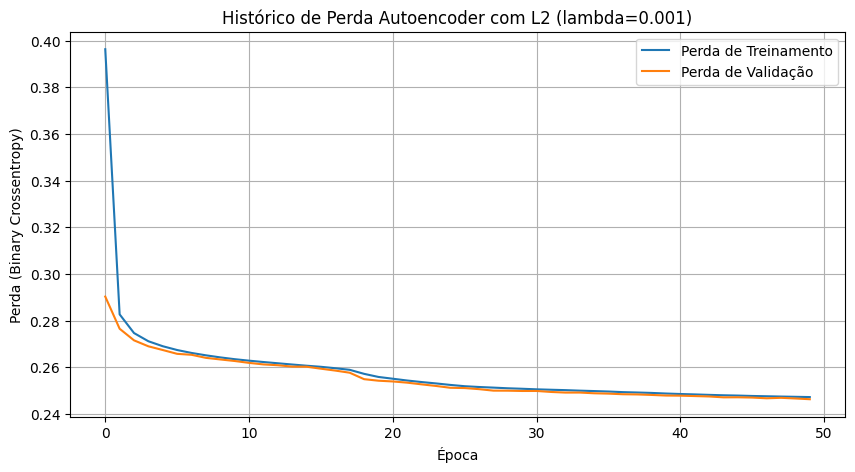


Avaliando Autoencoder com L2 no conjunto de teste...
Perda no Teste (Autoencoder com L2): 0.246251


In [25]:
# Avaliação do Autoencoder com L2 no conjunto de teste
plot_training_history(history_l2, f"Autoencoder com L2 (lambda={REG_FACTOR})")

print("\nAvaliando Autoencoder com L2 no conjunto de teste...")
loss_l2 = autoencoder_l2.evaluate(x_test_flat, x_test_flat, verbose=0)
print(f"Perda no Teste (Autoencoder com L2): {loss_l2:.6f}") # Inclui a perda de regularização


Visualizando reconstruções do Autoencoder com L2...
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


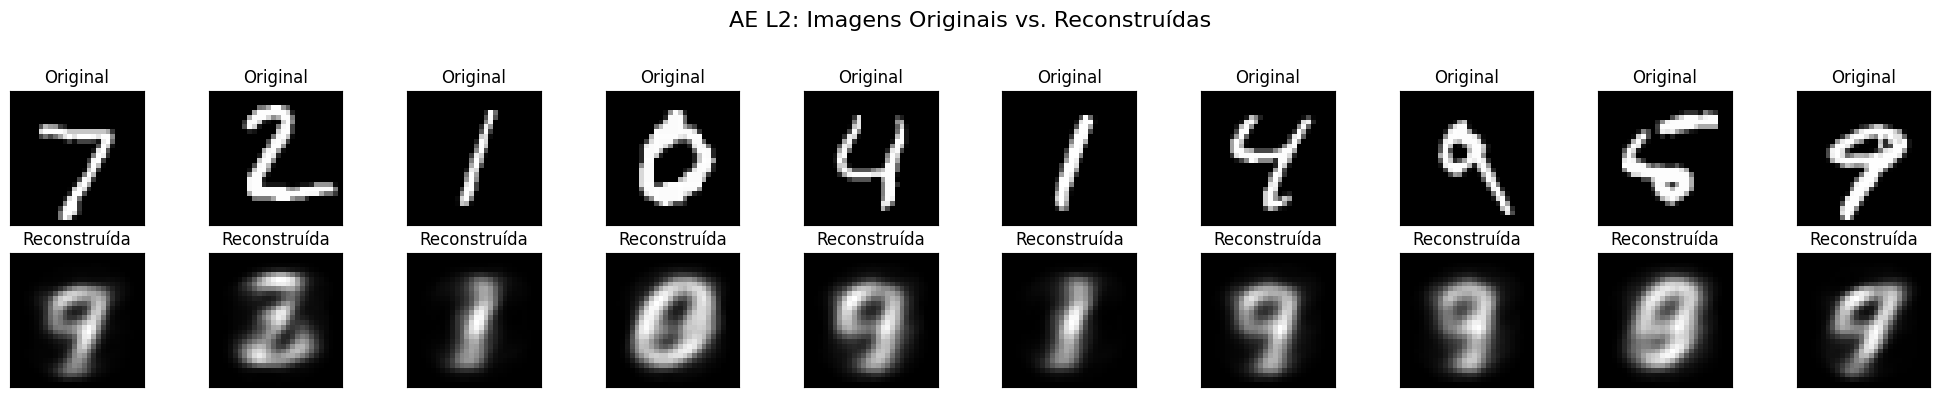

In [26]:
# Visualizar reconstruções do Autoencoder com L2
print("\nVisualizando reconstruções do Autoencoder com L2...")
reconstructed_imgs_l2 = autoencoder_l2.predict(x_test_flat)
visualize_reconstructions(x_test_flat, reconstructed_imgs_l2, title_prefix="AE L2: ")

## **Experimento 5: Visualização do Espaço Latente com t-SNE**
Nesta etapa o objetivo é entender melhor como o codificador (a parte do autoencoder que mapeia a entrada para o bottleneck) organiza os diferentes dígitos MNIST no espaço latente de baixa dimensão.

### **Funcionamento**
* **Criação do Modelo Encoder:** um novo modelo Keras é criado contendo apenas as camadas do codificador do `autoencoder_base` (da entrada até a camada bottleneck).

* **Codificação dos Dados de Teste:** as imagens de teste (`x_test_flat`) são passadas pelo `encoder_model` para obter suas representações no espaço latente (`encoded_test_data`).

* **Redução para 2D com t-SNE (t-distributed Stochastic Neighbor Embedding)**
  
  O t-SNE é um algoritmo não linear que tenta preservar as estruturas de vizinhança dos dados de alta dimensão no mapa de baixa dimensão. Ele modela as similaridades entre pontos usando distribuições de probabilidade. Caso a dimensão do bottleneck seja maior do que 2 (como o padrão de 32), a técnica t-SNE  é usada para reduzir ainda mais a dimensionalidade dessas representações latentes para 2D, a fim de permitir uma visualização.

Os pontos 2D resultantes do t-SNE (ou diretamente do bottleneck se ele for 2D) são plotados em um gráfico de dispersão. Crucialmente, os pontos são **coloridos de acordo com seus rótulos verdadeiros** (`y_test_raw`).

Idealmente, espera-se ver agrupamentos (clusters) de pontos correspondentes a diferentes dígitos, indicando que o encoder aprendeu a separar as classes no espaço latente, mesmo sem ter sido treinado explicitamente para isso, cumprindo o objetido do aprendizado não supervisionado.

### --- **EXPERIMENTO 5: VISUALIZAÇÃO DO ESPAÇO LATENTE** ---

Será utilizado o encoder do modelo `autoencoder_base`, que tem BOTTLENECK_DIM_DEFAULT = 32. Se BOTTLENECK_DIM_DEFAULT for > 2, precisaremos de t-SNE para visualização 2D.

In [33]:
# Criar modelo do Encoder a partir do autoencoder_base
input_to_bottleneck = autoencoder_base.input # Get the input of the model directly
output_from_bottleneck = autoencoder_base.get_layer(f'Bottleneck_{BOTTLENECK_DIM_DEFAULT}').output
encoder_model = Model(inputs=input_to_bottleneck, outputs=output_from_bottleneck, name='Encoder_Separado')

In [30]:
print("\nCodificando imagens de teste para o espaço latente...")
# Usar apenas um subconjunto dos dados de teste para t-SNE para economizar tempo
num_samples_tsne = 5000
encoded_test_data = encoder_model.predict(x_test_flat[:num_samples_tsne])
y_test_labels_subset = y_test_raw[:num_samples_tsne] # Rótulos correspondentes

print(f"Forma dos dados codificados: {encoded_test_data.shape}")

if BOTTLENECK_DIM_DEFAULT > 2:
    print("\nAplicando t-SNE para redução a 2D (pode demorar)...")
    tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=300, verbose=1)
    embedded_data_2d = tsne.fit_transform(encoded_test_data)
    print("t-SNE concluído.")
else: # Se o bottleneck já for 2D
    embedded_data_2d = encoded_test_data
    print("Usando diretamente a saída do bottleneck 2D.")


Codificando imagens de teste para o espaço latente...
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Forma dos dados codificados: (5000, 32)

Aplicando t-SNE para redução a 2D (pode demorar)...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 5000 samples in 0.001s...


/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


[t-SNE] Computed neighbors for 5000 samples in 0.333s...
[t-SNE] Computed conditional probabilities for sample 1000 / 5000
[t-SNE] Computed conditional probabilities for sample 2000 / 5000
[t-SNE] Computed conditional probabilities for sample 3000 / 5000
[t-SNE] Computed conditional probabilities for sample 4000 / 5000
[t-SNE] Computed conditional probabilities for sample 5000 / 5000
[t-SNE] Mean sigma: 5.600753
[t-SNE] KL divergence after 250 iterations with early exaggeration: 83.986343
[t-SNE] KL divergence after 300 iterations: 2.639313
t-SNE concluído.



--- Visualização do Espaço Latente (com t-SNE) ---

Plotando o espaço latente 2D...


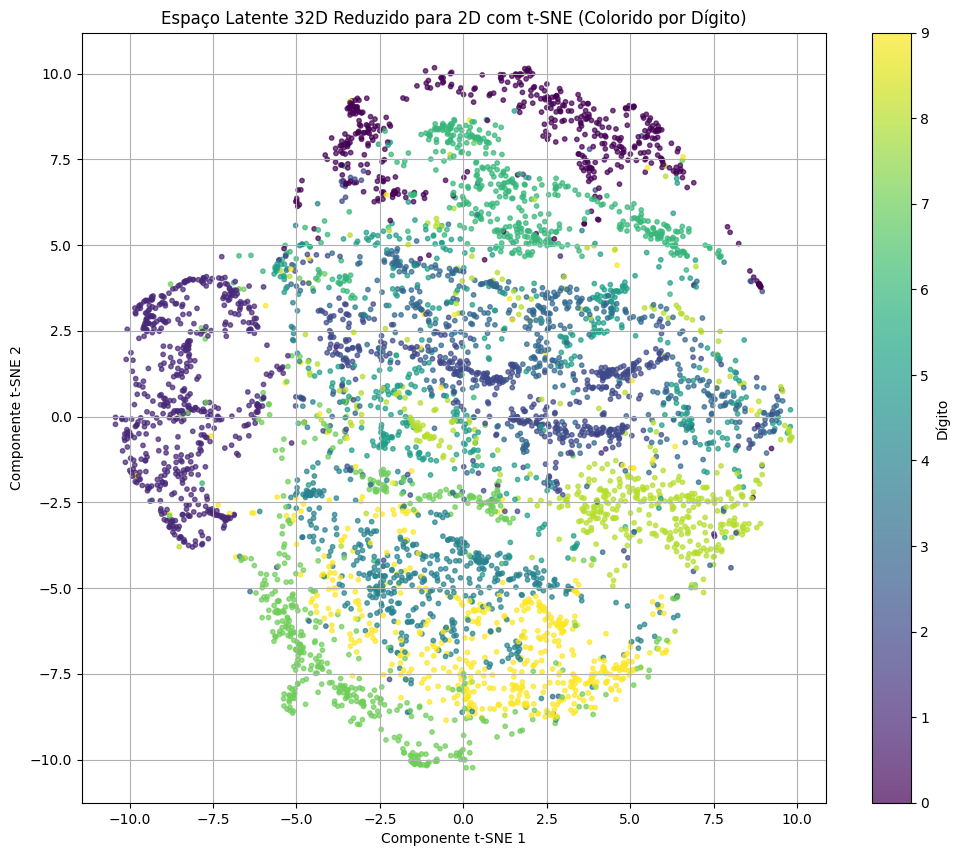

In [34]:
print("\n--- Visualização do Espaço Latente (com t-SNE) ---")
print("\nPlotando o espaço latente 2D...")
plt.figure(figsize=(12, 10))
scatter = plt.scatter(embedded_data_2d[:, 0], embedded_data_2d[:, 1], c=y_test_labels_subset, cmap='viridis', alpha=0.7, s=10)
plt.colorbar(scatter, ticks=range(10), label='Dígito')
plt.title(f'Espaço Latente {BOTTLENECK_DIM_DEFAULT}D Reduzido para 2D com t-SNE (Colorido por Dígito)')
plt.xlabel('Componente t-SNE 1')
plt.ylabel('Componente t-SNE 2')
plt.grid(True)
plt.show()

# **Referências**

  * Rumelhart, D. E., Hinton, G. E., & Williams, R. J. (1986). **Learning internal representations by error propagation**. In Parallel distributed processing: Explorations in the microstructure of cognition, vol. 1, pp. 318-362. MIT Press.
  * Goodfellow, I., Bengio, Y., & Courville, A. (2016). **Deep Learning**. MIT Press. (Principalmente Capítulo 14: Autoencoders) [Link: [https://www.deeplearningbook.org](https://www.deeplearningbook.org)]